In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pymannkendall as mk

In [2]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [3]:
df = pd.read_csv("data//Karnal.csv")

In [4]:
df["TIME"]=pd.to_datetime(df["TIME"])

In [57]:
df=df[df["TIME"].dt.year>1987]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7670 entries, 10958 to 18627
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   TIME    7670 non-null   datetime64[ns]
 1   MAX     7670 non-null   float64       
 2   MIN     7670 non-null   float64       
 3   RF      7670 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 299.6 KB


In [7]:
df_Years=np.sort(np.array(df["TIME"].dt.year.value_counts().index))

In [8]:
winter=df[(df["TIME"].dt.month>=1) & (df["TIME"].dt.month<=2) ]
premon=df[(df["TIME"].dt.month>=3) & (df["TIME"].dt.month<=5) ]
mons=df[(df["TIME"].dt.month>=6) & (df["TIME"].dt.month<=9) ]
postmon=df[(df["TIME"].dt.month>=10) & (df["TIME"].dt.month<=12)]

<h1> Datasets
</h1>

In [9]:
monthly_rainfall=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_rainfall.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["RF"].sum().reset_index()["RF"].values))
monthly_rainfall=pd.DataFrame(monthly_rainfall)

In [10]:
monthly_maxtemp=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_maxtemp.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["MAX"].mean().reset_index()["MAX"].values))
monthly_maxtemp=pd.DataFrame(monthly_maxtemp)

In [11]:
monthly_mintemp=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_mintemp.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["MIN"].mean().reset_index()["MIN"].values))
monthly_mintemp=pd.DataFrame(monthly_mintemp)

In [12]:
annual_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()

In [13]:
annual_maxtemp=df.groupby(df["TIME"].dt.year)["MAX"].mean().reset_index()

In [14]:
annual_mintemp=df.groupby(df["TIME"].dt.year)["MIN"].mean().reset_index()

<h1>Extreme Events</h1'/
                               >


In [15]:
dfEXTREMERIAN=df[(df["RF"]>=64.5)]

In [16]:
dfExtMonthly=pd.DataFrame(np.zeros([df_Years.shape[0],12]),columns=np.arange(1,13))
dfExtMonthly.index=df_Years
for i in np.array(dfEXTREMERIAN["TIME"].dt.year.value_counts().index) :
    for j in np.array(dfEXTREMERIAN[dfEXTREMERIAN["TIME"].dt.year==i]["TIME"].dt.month.value_counts().index):
        dfExtMonthly.loc[i,j]=dfEXTREMERIAN[(dfEXTREMERIAN["TIME"].dt.year==i) & (dfEXTREMERIAN["TIME"].dt.month==j)].shape[0]

In [17]:
dfExtYearly=pd.DataFrame(dfExtMonthly.T.sum(),columns=["freq"])

In [18]:
dfExtMonthSum=pd.DataFrame(dfExtMonthly.sum(),columns=["freq"])

In [19]:
dfExtWinter=pd.DataFrame(dfExtMonthly.T.loc[1:2].sum(),columns=["freq"])
dfExtPremon=pd.DataFrame(dfExtMonthly.T.loc[3:5].sum(),columns=["freq"])
dfExtMon=pd.DataFrame(dfExtMonthly.T.loc[6:9].sum(),columns=["freq"])
dfExtPostmon=pd.DataFrame(dfExtMonthly.T.loc[10:12].sum(),columns=["freq"])

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.28761613143645226), z=np.float64(1.0633657216461134), Tau=np.float64(0.16666666666666666), s=np.float64(35.0), var_s=np.float64(1022.3333333333334), slope=np.float64(0.0), intercept=np.float64(1.0))
MEAN:  1.619047619047619
SD:  1.499206139134658
CV:  92.59802624067005


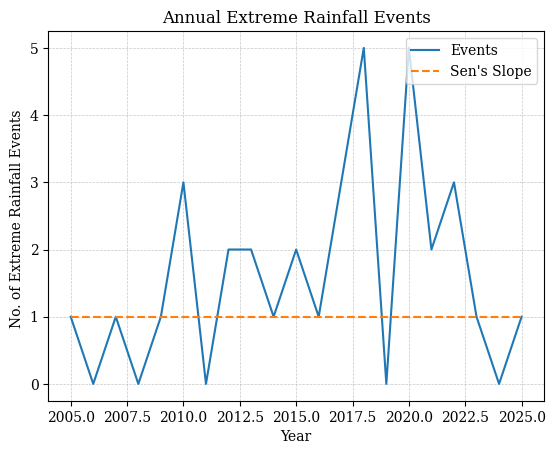

In [20]:
b=dfExtYearly
plt.plot(b.index,b["freq"],label="Events")
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Annual Extreme Rainfall Events")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.21549950906932702), z=np.float64(-1.2385842357671557), Tau=np.float64(-0.0761904761904762), s=np.float64(-16.0), var_s=np.float64(146.66666666666666), slope=np.float64(0.0), intercept=np.float64(0.0))
MEAN:  0.047619047619047616
SD:  0.21821789023599242
CV:  458.25756949558405


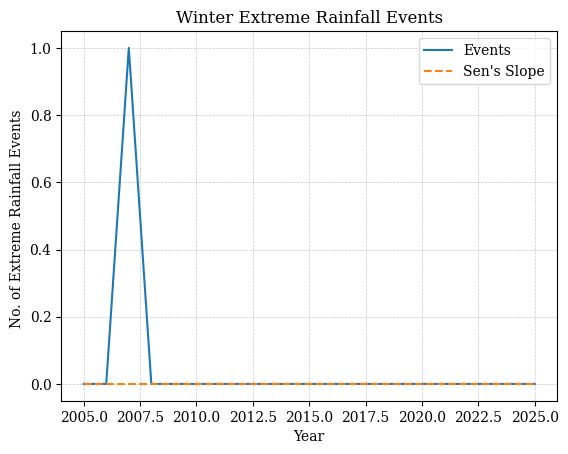

In [21]:
b=dfExtWinter
plt.plot(b.index,b["freq"],label="Events")
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Winter Extreme Rainfall Events")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.2550451754243619), z=np.float64(1.1381803659589922), Tau=np.float64(0.09523809523809523), s=np.float64(20.0), var_s=np.float64(278.6666666666667), slope=np.float64(0.0), intercept=np.float64(0.0))
MEAN:  0.09523809523809523
SD:  0.3007926037591192
CV:  315.8322339470752


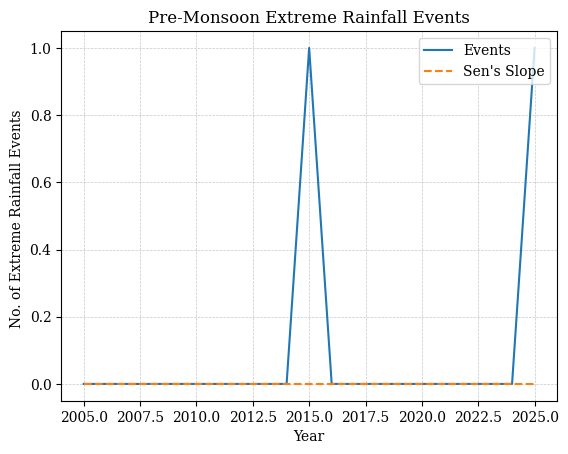

In [22]:
b=dfExtPremon
plt.plot(b.index,b["freq"],label="Events")
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Pre-Monsoon Extreme Rainfall Events")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.3796278161248403), z=np.float64(0.8785822634036288), Tau=np.float64(0.1380952380952381), s=np.float64(29.0), var_s=np.float64(1015.6666666666666), slope=np.float64(0.0), intercept=np.float64(1.0))
MEAN:  1.4761904761904763
SD:  1.569045812557671
CV:  106.29020020551965


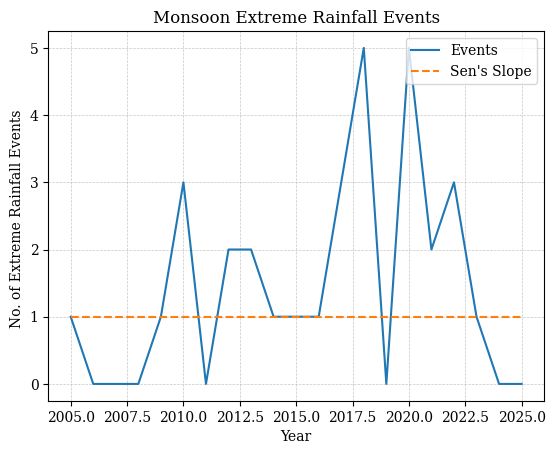

In [23]:
b=dfExtMon
plt.plot(b.index,b["freq"],label="Events")
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Monsoon Extreme Rainfall Events")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(1.0), z=0, Tau=np.float64(0.0), s=np.float64(0.0), var_s=np.float64(0.0), slope=np.float64(0.0), intercept=np.float64(0.0))


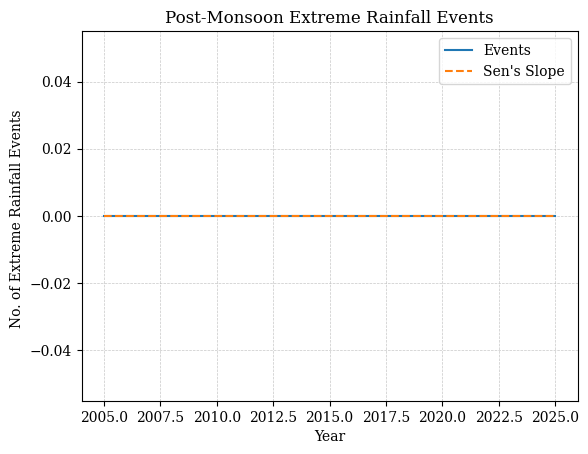

In [24]:
b=dfExtPostmon
plt.plot(b.index,b["freq"],label="Events")
test=mk.original_test(b["freq"])
print(test)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Post-Monsoon Extreme Rainfall Events")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.8853327201609549), z=np.float64(0.14421243717653184), Tau=np.float64(0.045454545454545456), s=np.float64(3.0), var_s=np.float64(192.33333333333334), slope=np.float64(0.0), intercept=np.float64(1.0))
MEAN:  2.8333333333333335
SD:  4.217567875906538
CV:  148.85533679670132


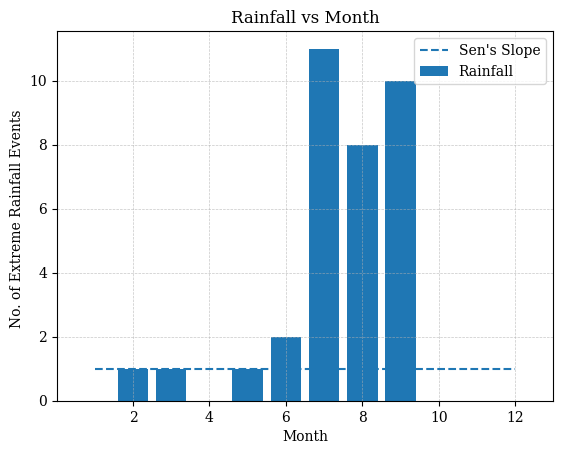

In [25]:
b=dfExtMonthSum
plt.bar(b.index,b["freq"],label="Rainfall")
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Month")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Rainfall vs Month")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [26]:
winterE=winter[(winter["RF"]>=64.5)]
premonE=premon[(premon["RF"]>=64.5)]
monsE=mons[(mons["RF"]>=64.5)]
postmonE=postmon[(postmon["RF"]>=64.5)]

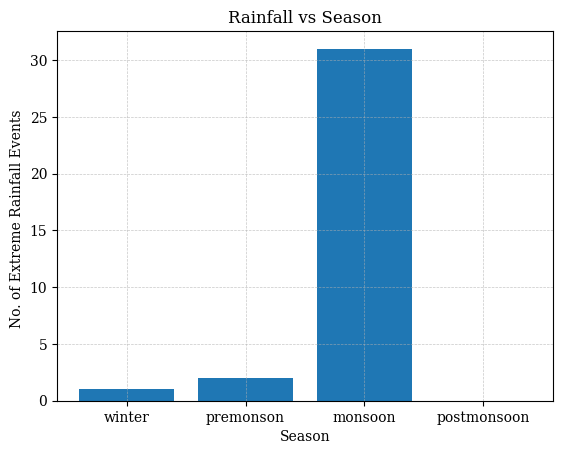

In [27]:
plt.bar(["winter","premonson","monsoon","postmonsoon"],[winterE.shape[0],premonE.shape[0],monsE.shape[0],postmonE.shape[0]])
plt.xlabel("Season")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Rainfall vs Season")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

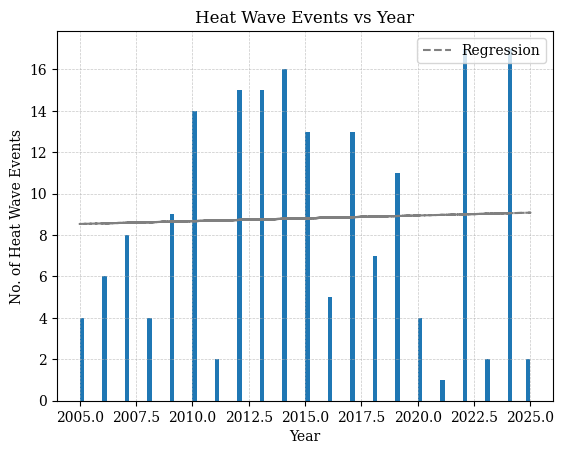

In [28]:
model=LinearRegression()
model.fit(np.array(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index).reshape(-1,1),df[df["MAX"]>=42]["TIME"].dt.year.value_counts().values)
plt.hist(df[df["MAX"]>=42]["TIME"].dt.year,bins=100)
plt.plot(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index,model.predict(np.array(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index).reshape(-1,1)),linestyle="--",c="grey",label="Regression")
plt.xlabel("Year")
plt.ylabel("No. of Heat Wave Events")
plt.title("Heat Wave Events vs Year")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

<h1>Minimum temperature curve</h1>

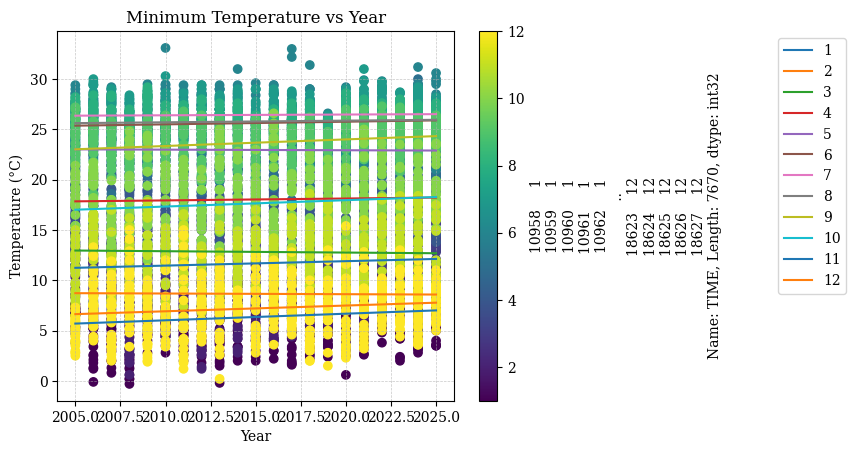

In [29]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MIN"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MIN'])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["MIN"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Slope :  [0.02820603]


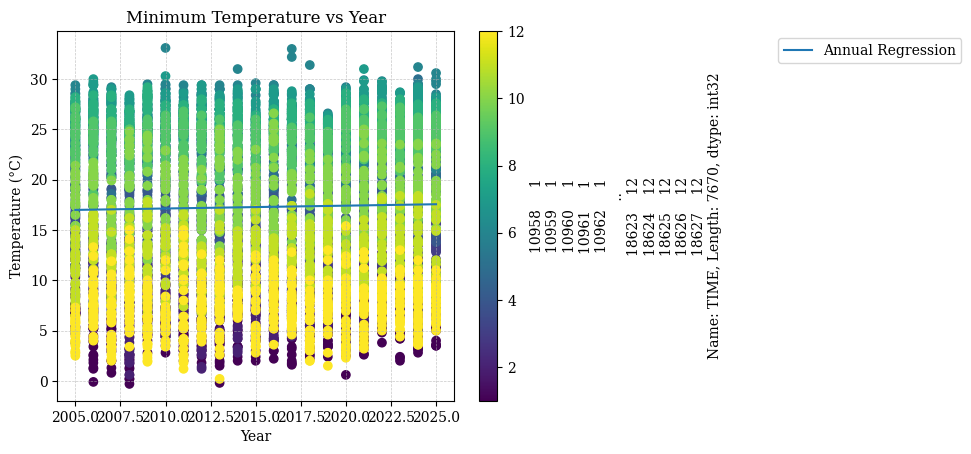

In [30]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MIN"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MIN'])
model.fit(dff["TIME"].dt.year.values.reshape(-1, 1), dff["MIN"])
y_pred = model.predict(dff["TIME"].dt.year.values.reshape(-1, 1))
plt.plot(dff["TIME"].dt.year, y_pred, label="Annual Regression")
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Year")
print("Slope : ",model.coef_)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

<h5>
    annual minimum temperature is observed to be decreasing atrate of around 0.002 C per year
</h5>

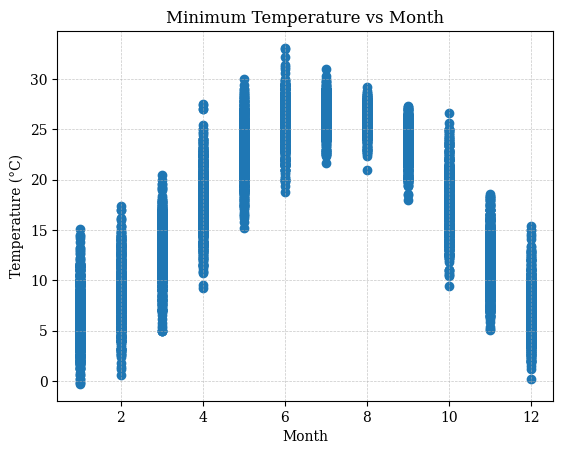

In [31]:
plt.scatter(df["TIME"].dt.month,df["MIN"])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.014447075828058153), z=np.float64(2.445950688799035), Tau=np.float64(0.3904761904761905), s=np.float64(82.0), var_s=1096.6666666666667, slope=np.float64(0.034388830206976514), intercept=np.float64(16.826522656834346))
MEAN:  17.279494220977284
SD:  0.3538501320800498
CV:  2.047803758344247


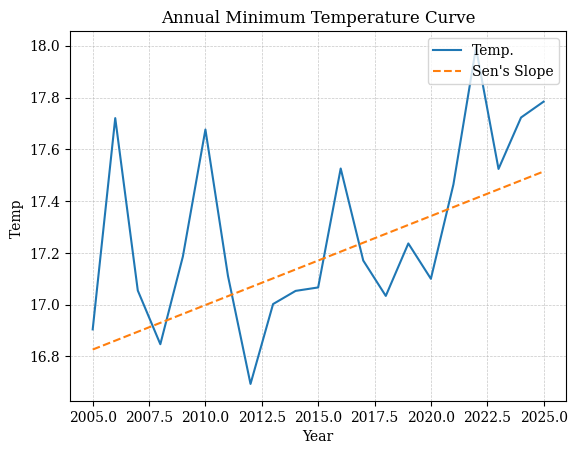

In [32]:
b=annual_mintemp
plt.plot(b["TIME"],b["MIN"],label="Temp.")
test=mk.original_test(b["MIN"])
print(test)
print("MEAN: ",b["MIN"].mean())
print("SD: ",b["MIN"].std())
print("CV: ",b["MIN"].std()/b["MIN"].mean()*100)
plt.plot(b["TIME"],test.slope*(b["TIME"]-b["TIME"].min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Temp ")
plt.title("Annual Minimum Temperature Curve")
plt.legend(loc="upper right") 
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [33]:
print("Highest Minimum Temp. : ",dff["MIN"].max())
print("Lowest Minimum Temp. : ",dff["MIN"].min())

Highest Minimum Temp. :  33.1
Lowest Minimum Temp. :  -0.3


<h1>Maximum temperature curve  </h1>

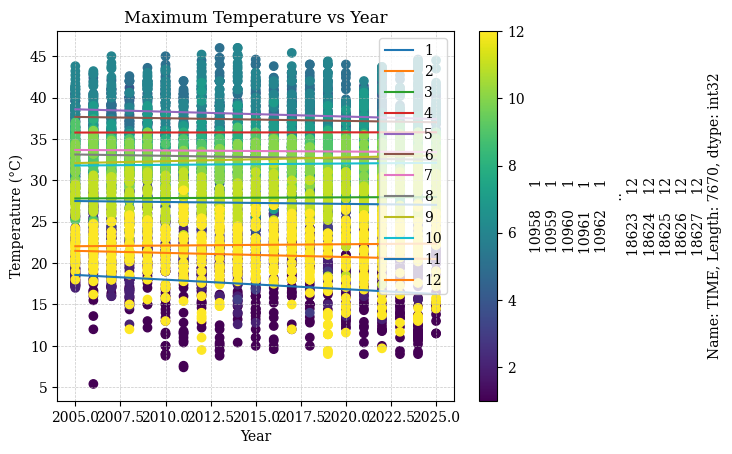

In [34]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MAX"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = dff.dropna(subset=['MAX'])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["MAX"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Year")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Slope:  [-0.02021888]


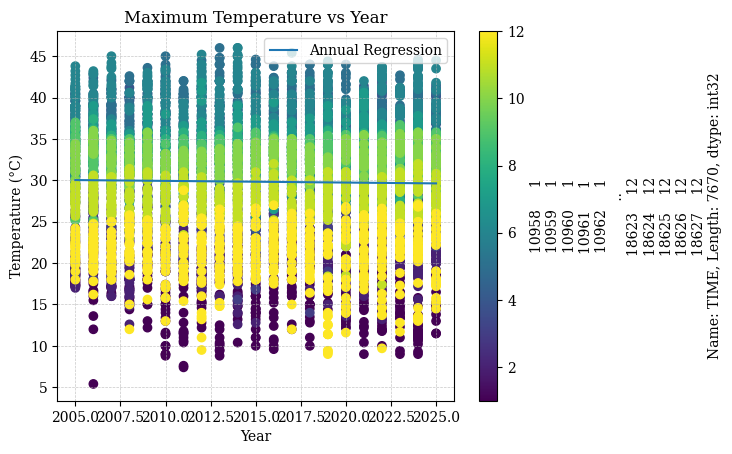

In [35]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MAX"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MAX'])
model.fit(dff["TIME"].dt.year.values.reshape(-1, 1), dff["MAX"])
y_pred = model.predict(dff["TIME"].dt.year.values.reshape(-1, 1))
plt.plot(dff["TIME"].dt.year, y_pred, label="Annual Regression")
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Year")
print("Slope: ",model.coef_)
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

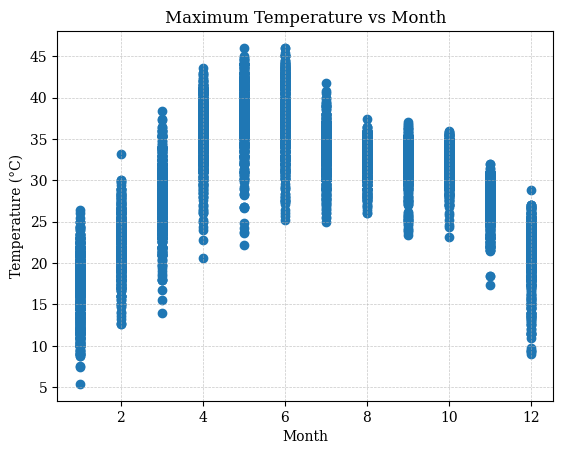

In [36]:
plt.scatter(df["TIME"].dt.month,df["MAX"])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.19412668587809967), z=np.float64(-1.2984676496093641), Tau=np.float64(-0.20952380952380953), s=np.float64(-44.0), var_s=1096.6666666666667, slope=np.float64(-0.017043817441175543), intercept=np.float64(29.997534565992108))
MEAN:  29.83253212853877
SD:  0.4009961476705009
CV:  1.344157264099265


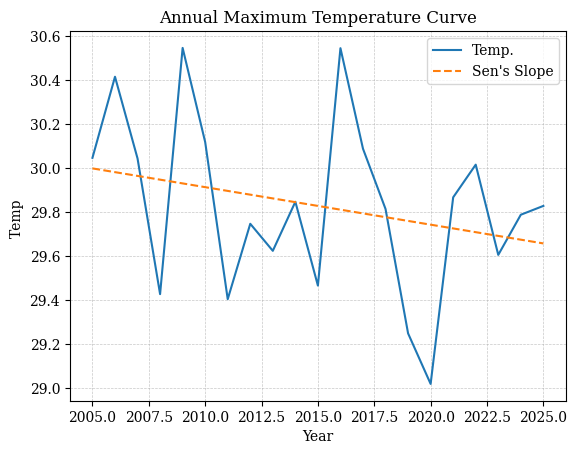

In [37]:
b=annual_maxtemp
plt.plot(b["TIME"],b["MAX"],label="Temp.")
test=mk.original_test(b["MAX"])
print(test)
print("MEAN: ",b["MAX"].mean())
print("SD: ",b["MAX"].std())
print("CV: ",b["MAX"].std()/b["MAX"].mean()*100)
plt.plot(b["TIME"],test.slope*(b["TIME"]-b["TIME"].min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Temp ")
plt.title("Annual Maximum Temperature Curve")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [38]:
print("Highest Maximum Temp. : ",dff["MAX"].max())
print("Lowest Maximum Temp. : ",dff["MAX"].min())

Highest Maximum Temp. :  46.0
Lowest Maximum Temp. :  5.4


<h1>Rainfall curve </h1>

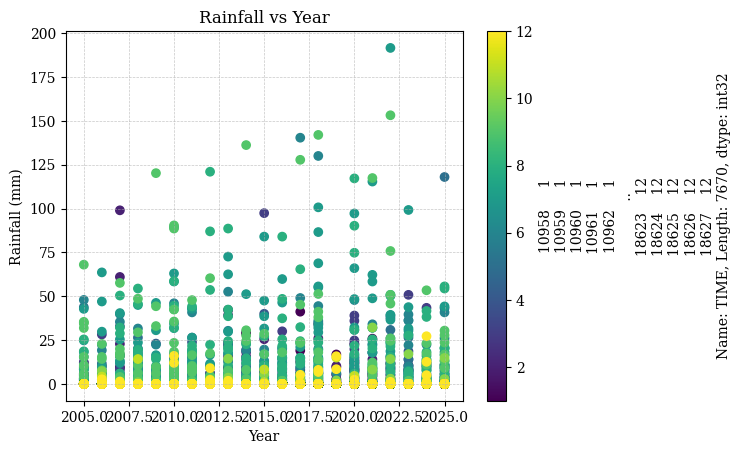

In [39]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["RF"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

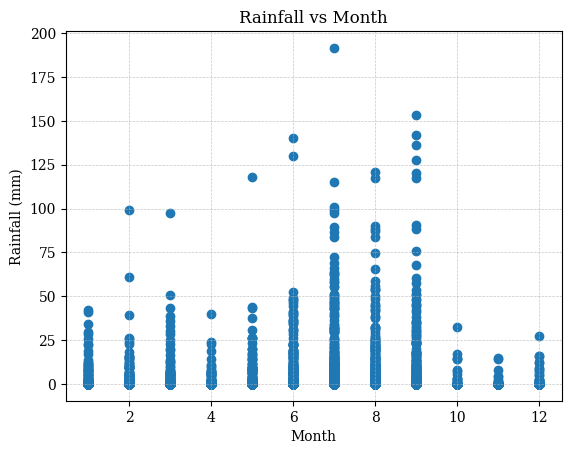

In [40]:
plt.scatter(df["TIME"].dt.month,df["RF"])
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

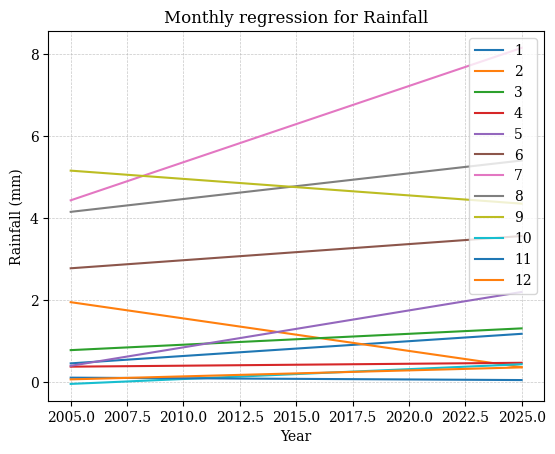

In [41]:
model = LinearRegression()
dff = df.dropna(subset=["RF"])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["RF"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1))
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly regression for Rainfall")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.15582458786203346), z=np.float64(1.419255337945119), Tau=np.float64(0.22857142857142856), s=np.float64(48.0), var_s=1096.6666666666667, slope=np.float64(13.638888888888879), intercept=np.float64(569.5111111111112))
MEAN:  740.5666666666667
SD:  294.25423757922897
CV:  39.733659483174456


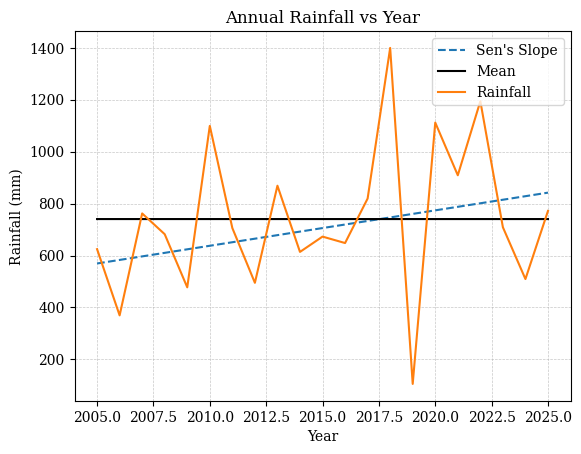

In [42]:
avg_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.plot(df["TIME"].dt.year,np.ones(df["TIME"].dt.year.shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Annual Rainfall vs Year")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.7857971061789661), z=np.float64(0.27177229875544834), Tau=np.float64(0.047619047619047616), s=np.float64(10.0), var_s=1096.6666666666667, slope=np.float64(0.4555555555555558), intercept=np.float64(36.044444444444444))
MEAN:  58.24285714285714
SD:  57.94718777842952
CV:  99.49235085823072


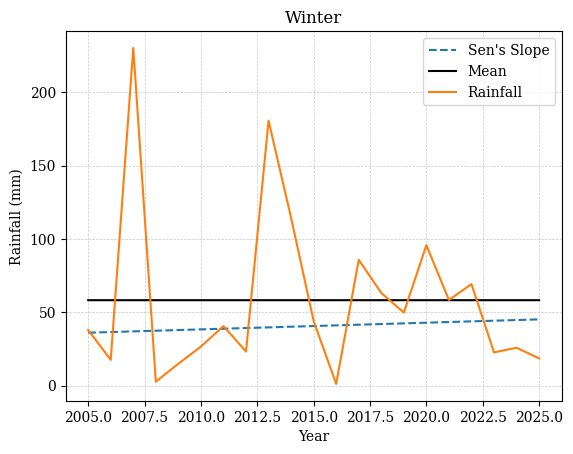

In [43]:
dff = winter
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Winter")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.4873503903353207), z=np.float64(0.6945292079305901), Tau=np.float64(0.11428571428571428), s=np.float64(24.0), var_s=1096.6666666666667, slope=np.float64(1.72), intercept=np.float64(50.3))
MEAN:  85.74761904761904
SD:  67.19409660861301
CV:  78.36263835068992


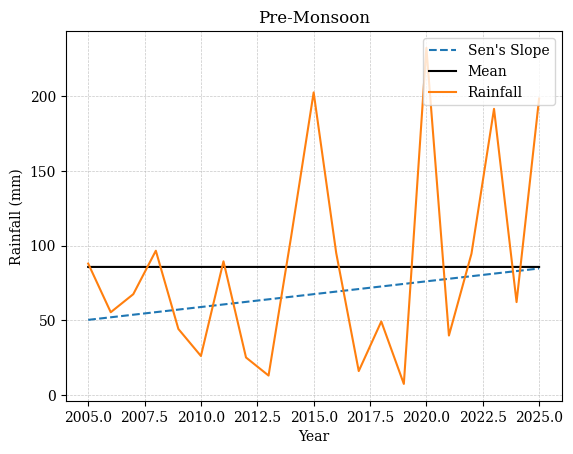

In [44]:
dff = premon
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Pre-Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.45029515330704095), z=np.float64(0.7549230520984676), Tau=np.float64(0.12380952380952381), s=np.float64(26.0), var_s=1096.6666666666667, slope=np.float64(9.68888888888889), intercept=np.float64(440.41111111111104))
MEAN:  581.0857142857143
SD:  279.40257566048723
CV:  48.08285056601954


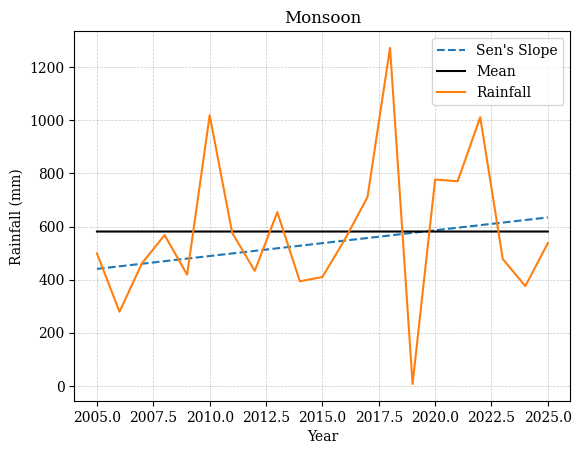

In [45]:
dff = mons
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.03916007470110805), z=np.float64(2.06250087117709), Tau=np.float64(0.32857142857142857), s=np.float64(69.0), var_s=np.float64(1087.0), slope=np.float64(0.9522222222222219), intercept=np.float64(5.677777777777781))
MEAN:  15.490476190476189
SD:  14.051473401814658
CV:  90.71040314728185


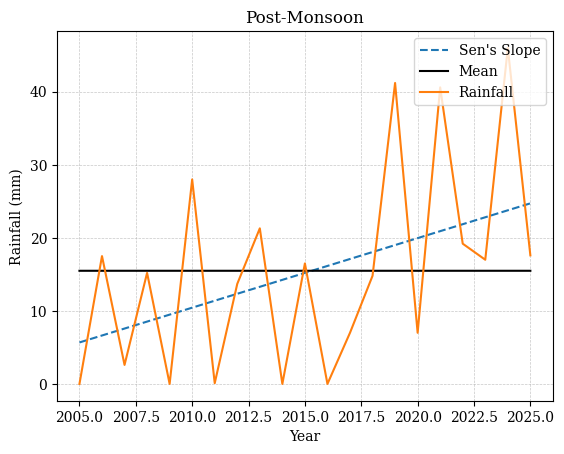

In [46]:
dff = postmon
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Post-Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

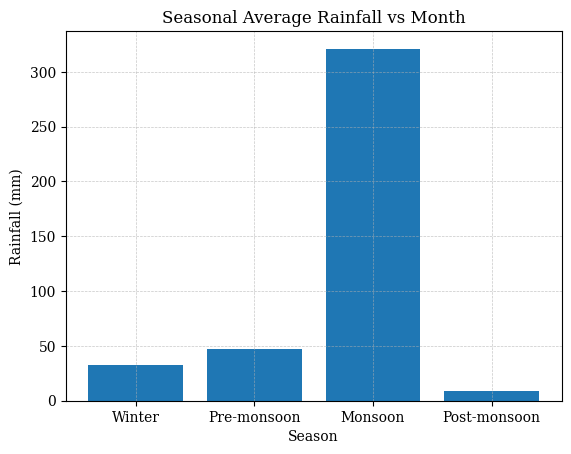

In [56]:
season_total=np.array([winter["RF"].sum(),premon["RF"].sum(),mons["RF"].sum(),postmon["RF"].sum()])/38
plt.bar(["Winter","Pre-monsoon","Monsoon","Post-monsoon"],season_total)
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.title("Seasonal Average Rainfall vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


In [ ]:
dff = df.dropna(subset=["RF"])
avg_rainfall=df.groupby(df["TIME"].dt.month)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.plot(df["TIME"].dt.month,np.ones(df["TIME"].dt.month.shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.bar(avg_rainfall["TIME"],avg_rainfall["RF"])
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly Rainfall vs Month")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [ ]:
avg_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
plt.plot(df["TIME"].dt.year,np.ones(df["TIME"].dt.year.shape[0])*0,c="black")
plt.bar(avg_rainfall["TIME"],avg_rainfall["RF"]-avg_rainfall["RF"].mean())
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Deviation From Annual Rainfall vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [ ]:
rf=np.array(df[df["RF"]>1]["RF"])
rf=np.log(rf)
plt.hist(rf,bins=70,density=True, alpha=0.5)
from scipy.stats import gaussian_kde
kde = gaussian_kde(rf)

x = np.linspace(rf.min(), rf.max(), 70)
plt.plot(x, kde(x),label="Probabilty Density",linestyle="--")
plt.xlabel("Log of Rainfall")
plt.ylabel("Density")
plt.title("Probabilty Density vs Rainfall")
plt.legend(loc="upper right")

In [ ]:
print("Maximum Rainfall : ",dff["RF"].max())
print("Minimum Rainfall : ",dff["RF"].min())

<h1> Monsoon Trends</h1>

In [ ]:
monss=mons[(mons["RF"]>=10)&(mons["TIME"].dt.month==6)]
plt.colorbar(plt.scatter(monss["TIME"].dt.year,monss["TIME"].dt.day,c=monss["TIME"].dt.month), label=monss["TIME"].dt.month)

In [ ]:
rainfall_ls={}
for i in df_Years:
    try:
        rainfall_ls[int(i)]=np.where(np.diff(np.array(mons[mons["TIME"].dt.year==int(i)]["RF"]))>4)[0]
    except Exception as e:
        pass

In [ ]:
ls={}
for i in rainfall_ls.keys():
    try:
        ls[i]=[rainfall_ls[i][0],rainfall_ls[i][-1],len(rainfall_ls[i])]
    except Exception as e:
        pass

In [ ]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,0])
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,0])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Regression",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,0])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Day")
plt.title("Monsoon Arrival vs Year")
plt.legend(loc="upper right")

In [ ]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,1])
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,1])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Regression",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,1])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Day")
plt.title("Monsoon Departure vs Year")
plt.legend(loc="upper right")

In [ ]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,2])
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,2])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Regression",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,2])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Days")
plt.title("No. of Rainfall Events vs Year")
plt.legend(loc="upper right")

In [ ]:
n_days=np.array(list(ls.values()))[:,1]-np.array(list(ls.values()))[:,0]
plt.plot(ls.keys(),n_days)
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),n_days)
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Regression",linestyle="--")
test=mk.original_test(n_days)
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Sen's Slope",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Days")
plt.title("Monsoon Days vs Year")
plt.legend(loc="upper right")

<h1>Trends</h1>

In [58]:
df.corr()

,TIME,MAX,MIN,RF
TIME,1.000000,-0.011338,0.029539,0.020828
MAX,-0.011338,1.000000,0.820039,0.002579
MIN,0.029539,0.820039,1.000000,0.130907
RF,0.020828,0.002579,0.130907,1.000000


In [ ]:
model=LinearRegression()
dff=df.dropna()
model.fit(dff["MIN"].values.reshape(-1, 1),dff["MAX"])
t=model.predict(dff["MIN"].values.reshape(-1, 1))
plt.plot(dff["MIN"],t)
plt.scatter(dff["MIN"],dff["MAX"],c=["yellow"])
plt.xlabel("Minimum Temp.")
plt.ylabel("Maximum Temp.")
plt.title("Relation b/w Max. and Min. Temperature")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[["MAX","MIN","RF"]],
    figsize=(8,8)

)

In [ ]:
# dfExtMonthly.to_csv("extmonthyl.csv",index=False)